# ReKIS dataset introduction
Inspired by: https://github.com/podondra/downscaling/blob/main/notebooks/01_reprojection.ipynb

In [32]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib
import cartopy
import rasterio

# ReKIS

In [2]:
CLIMATE_VARIABLE = 'TM'
YEAR = 2005
FILE_PATH = f'../../rci_data/climate/ReKIS/KlimRefDS_v3.1_1961-2023/Raster/Tag/GK4/{CLIMATE_VARIABLE}/{CLIMATE_VARIABLE}_{YEAR}.nc'

In [3]:
x = xr.open_mfdataset(FILE_PATH, decode_coords="all")
x = x[CLIMATE_VARIABLE]
x

<xarray.DataArray 'TM' (time: 365, northing: 401, easting: 418)> Size: 245MB
dask.array<open_dataset-TM, shape=(365, 401, 418), dtype=float32, chunksize=(122, 134, 140), chunktype=numpy.ndarray>
Coordinates:
  * easting   (easting) float64 3kB 4.336e+06 4.336e+06 ... 4.752e+06 4.752e+06
  * northing  (northing) float64 3kB 5.954e+06 5.954e+06 ... 5.556e+06 5.554e+06
  * time      (time) datetime64[ns] 3kB 2005-01-01 2005-01-02 ... 2005-12-31
    crs       int32 4B ...
Attributes:
    units:      °C
    long_name:  mittlere Temperatur

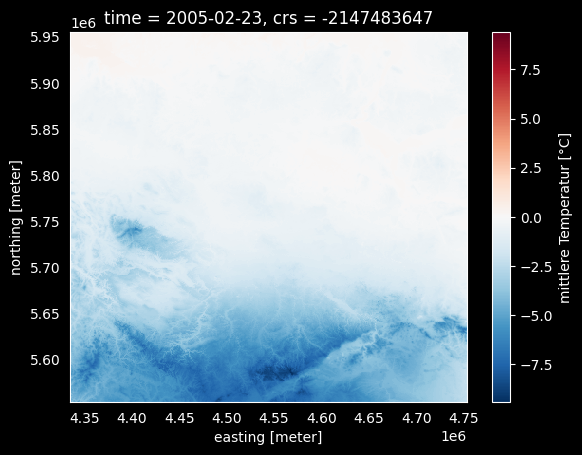

In [4]:
date = f'{YEAR}-02-23'
date_tm = x.sel({'time': date})
date_tm.plot()

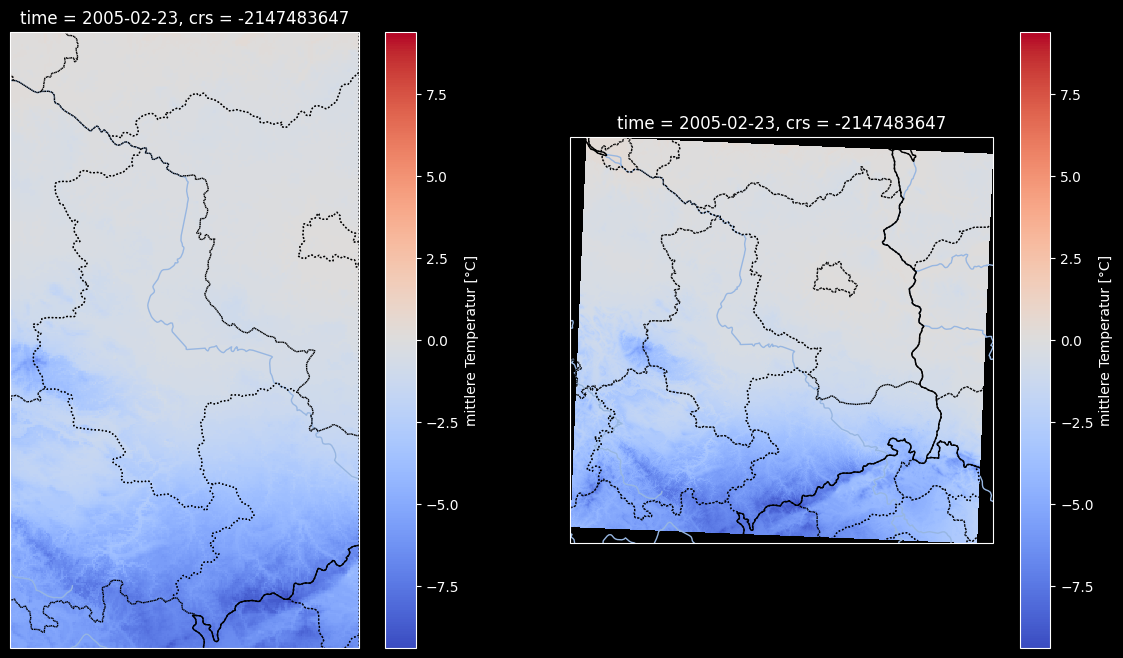

In [75]:
fig = plt.figure(figsize=(15, 8))
ax0 = fig.add_subplot(1, 2, 1, projection=cartopy.crs.epsg(31468))
date_tm.plot(ax = ax0, center = 0, cmap = 'coolwarm')

ax1 = fig.add_subplot(1, 2, 2, projection=cartopy.crs.UTM(33))
date_tm.plot(ax = ax1, center = 0, cmap = 'coolwarm', transform = cartopy.crs.epsg(31468))

for ax in [ax0, ax1]:
    ax.add_feature(cartopy.feature.RIVERS)
    ax.add_feature(cartopy.feature.COASTLINE)
    ax.add_feature(cartopy.feature.BORDERS)
    ax.add_feature(cartopy.feature.STATES, linestyle=':')

In [6]:
x.rio.set_spatial_dims("easting", "northing")
x.rio.crs, x.rio.width, x.rio.height, x.rio.resolution()

(CRS.from_wkt('PROJCS["DHDN / 3-degree Gauss-Kruger zone 4",GEOGCS["DHDN",DATUM["Deutsches_Hauptdreiecksnetz",SPHEROID["Bessel 1841",6377397.155,299.1528128]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4314"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",12],PARAMETER["scale_factor",1],PARAMETER["false_easting",4500000],PARAMETER["false_northing",0],UNIT["metre",1],AXIS["Northing",NORTH],AXIS["Easting",EAST],AUTHORITY["EPSG","31468"]]'),
 418,
 401,
 (1000.0, -1000.0))

# CORDEX

In [7]:
FILE_PATH_CORDEX = f'../../rci_data/climate/CORDEX/tas/tas_EUR-11_ECMWF-ERAINT_evaluation_r1i1p1_GERICS-REMO2015_v1_day_*.nc'

In [18]:
cordex = xr.open_mfdataset(
    FILE_PATH_CORDEX,
    decode_coords="all",
)
cordex = cordex["tas"]
cordex

<xarray.DataArray 'tas' (time: 12418, rlat: 412, rlon: 424)> Size: 9GB
dask.array<concatenate, shape=(12418, 412, 424), dtype=float32, chunksize=(1, 412, 424), chunktype=numpy.ndarray>
Coordinates:
  * time                        (time) datetime64[ns] 99kB 1979-01-02T12:00:0...
  * rlat                        (rlat) float64 3kB -23.38 -23.27 ... 21.72 21.84
  * rlon                        (rlon) float64 3kB -28.38 -28.27 ... 18.04 18.16
    rotated_latitude_longitude  int32 4B -2147483647
    lat                         (rlat, rlon) float32 699kB dask.array<chunksize=(412, 424), meta=np.ndarray>
    lon                         (rlat, rlon) float32 699kB dask.array<chunksize=(412, 424), meta=np.ndarray>
    height                      float64 8B 2.0
Attributes:
    standard_name:     air_temperature
    long_name:         Near-Surface Air Temperature
    comment:           daily-mean near-surface (usually, 2 meter) air tempera...
    units:             K
    cell_methods:      time: mean
    associated_files:  gridspecFile: gridspec_atmos_fx_GERICS-REMO2015_evalua...

In [40]:
cordex_example = cordex.sel(time=date + "T12:00:00")
cordex_example -= 273.15
cordex_example

<xarray.DataArray 'tas' (rlat: 412, rlon: 424)> Size: 699kB
dask.array<sub, shape=(412, 424), dtype=float32, chunksize=(412, 424), chunktype=numpy.ndarray>
Coordinates:
    time                        datetime64[ns] 8B 2005-02-23T12:00:00
  * rlat                        (rlat) float64 3kB -23.38 -23.27 ... 21.72 21.84
  * rlon                        (rlon) float64 3kB -28.38 -28.27 ... 18.04 18.16
    rotated_latitude_longitude  int32 4B -2147483647
    lat                         (rlat, rlon) float32 699kB dask.array<chunksize=(412, 424), meta=np.ndarray>
    lon                         (rlat, rlon) float32 699kB dask.array<chunksize=(412, 424), meta=np.ndarray>
    height                      float64 8B 2.0
Attributes:
    standard_name:     air_temperature
    long_name:         Near-Surface Air Temperature
    comment:           daily-mean near-surface (usually, 2 meter) air tempera...
    units:             K
    cell_methods:      time: mean
    associated_files:  gridspecFile: gridspec_atmos_fx_GERICS-REMO2015_evalua...

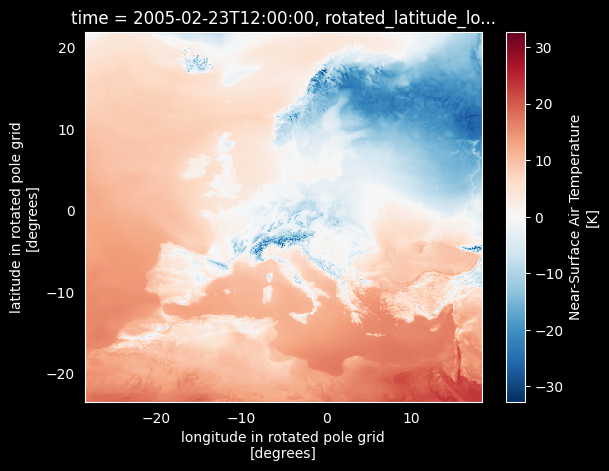

In [58]:
cordex_example.plot()

In [42]:
cordex["rotated_latitude_longitude"].attrs

{'grid_mapping_name': 'rotated_latitude_longitude',
 'grid_north_pole_latitude': np.float64(39.25),
 'grid_north_pole_longitude': np.float64(-162.0),
 'north_pole_grid_longitude': np.float64(0.0)}

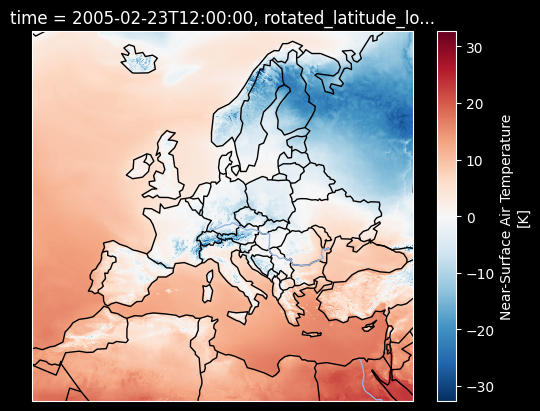

In [45]:
rotated_pole_crs = cartopy.crs.RotatedPole(
    pole_latitude=cordex["rotated_latitude_longitude"].attrs[
        "grid_north_pole_latitude"
    ],
    pole_longitude=cordex["rotated_latitude_longitude"].attrs[
        "grid_north_pole_longitude"
    ],
)
fig, ax = plt.subplots(subplot_kw=dict(projection=rotated_pole_crs))
cordex_example.plot(ax=ax)
ax.add_feature(cartopy.feature.BORDERS)
ax.add_feature(cartopy.feature.STATES, linestyle=":")
ax.add_feature(cartopy.feature.RIVERS)
ax.add_feature(cartopy.feature.COASTLINE)

# v stupnoch Celzia

In [21]:
cordex.rio.crs, cordex.rio.width, cordex.rio.height, cordex.rio.resolution()

(CRS.from_wkt('GEOGCRS["undefined",BASEGEOGCRS["undefined",ENSEMBLE["World Geodetic System 1984 ensemble",MEMBER["World Geodetic System 1984 (Transit)",ID["EPSG",1166]],MEMBER["World Geodetic System 1984 (G730)",ID["EPSG",1152]],MEMBER["World Geodetic System 1984 (G873)",ID["EPSG",1153]],MEMBER["World Geodetic System 1984 (G1150)",ID["EPSG",1154]],MEMBER["World Geodetic System 1984 (G1674)",ID["EPSG",1155]],MEMBER["World Geodetic System 1984 (G1762)",ID["EPSG",1156]],MEMBER["World Geodetic System 1984 (G2139)",ID["EPSG",1309]],MEMBER["World Geodetic System 1984 (G2296)",ID["EPSG",1383]],ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1],ID["EPSG",7030]],ENSEMBLEACCURACY[2.0],ID["EPSG",6326]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8901]]],DERIVINGCONVERSION["Pole rotation (netCDF CF convention)",METHOD["Pole rotation (netCDF CF convention)"],PARAMETER["Grid north pole latitude (netCDF CF convention)",39.25,ANGLEUNIT["degree",0.0174532925199433,

reprojekcia s resamplingom

In [22]:
# reproject cordex to target projection
# so that we can determine the resolution of input
# https://rasterio.readthedocs.io/en/latest/api/rasterio.enums.html#rasterio.enums.Resampling
RESAMPLING = rasterio.enums.Resampling.cubic_spline
# https://corteva.github.io/rioxarray/stable/rioxarray.html#rioxarray.raster_array.RasterArray.reproject
cordex_resolution = cordex_example.rio.reproject(date_tm.rio.crs, resampling=RESAMPLING)
cordex.rio.resolution(), cordex_resolution.rio.resolution()

((0.11, 0.11), (12433.711654642335, -12433.711654642335))

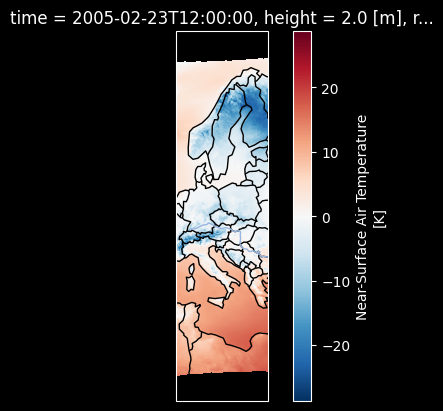

In [26]:
fig, ax = plt.subplots(subplot_kw=dict(projection=cartopy.crs.UTM(33)))
cordex_resolution.plot(ax=ax, transform=cartopy.crs.epsg(31468))
ax.add_feature(cartopy.feature.BORDERS)
ax.add_feature(cartopy.feature.STATES, linestyle=":")
ax.add_feature(cartopy.feature.RIVERS)
ax.add_feature(cartopy.feature.COASTLINE)

# Upscale ReKIS

Super-resolution methods usually need integer scale factors.
Therefore, we clip to box of 400 times 400 pixels and upscale to 10 km.
The result has 40 times 40 pixels.
Then, the scale factor is 10 (i.e. 2 times 5).

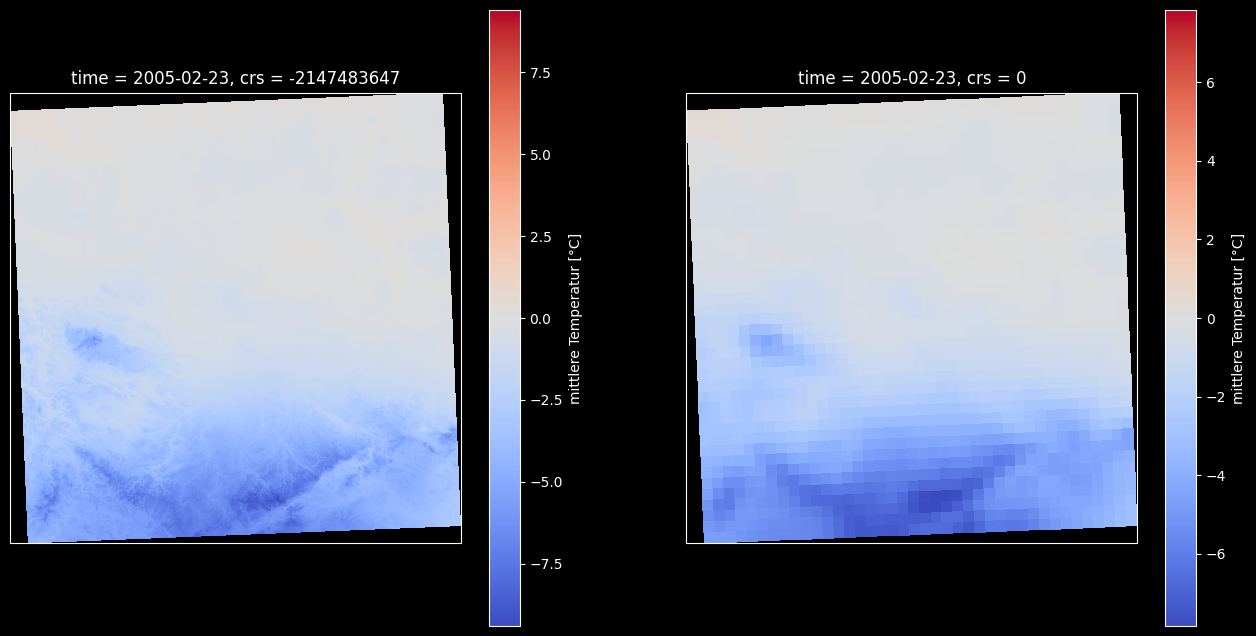

In [76]:
y_example = date_tm.isel(northing=slice(0, 400), easting=slice(0, 400))
y_example.rio.set_spatial_dims("easting", "northing")
x_example = y_example.rio.reproject(
    y_example.rio.crs,
    resolution=(10_000, 10_000), # 10 x 10 km
    resampling=RESAMPLING,
)

fig = plt.figure(figsize=(16, 8))
ax0 = fig.add_subplot(1, 2, 1, projection = cartopy.crs.UTM(32))
y_example.plot(ax = ax0, transform = cartopy.crs.epsg(31468), cmap = "coolwarm")

ax1 = fig.add_subplot(1, 2, 2, projection = cartopy.crs.UTM(32))
x_example.plot(ax = ax1, transform = cartopy.crs.epsg(31468), cmap = 'coolwarm')

In [29]:
(
    y_example.shape,
    x_example.shape,
    y_example.rio.resolution(),
    x_example.rio.resolution(),
    cordex_resolution.rio.resolution(),
    y_example.rio.bounds(),
    x_example.rio.bounds(),
)

((400, 400),
 (40, 40),
 (1000.0, -1000.0),
 (10000.0, -10000.0),
 (12433.711654642335, -12433.711654642335),
 (4335000.0, 5555000.0, 4735000.0, 5955000.0),
 (4335000.0, 5555000.0, 4735000.0, 5955000.0))

# Reproject and match

In [30]:
# https://corteva.github.io/rioxarray/stable/examples/reproject_match.html
x_cordex_example = cordex_example.rio.reproject_match(x_example, resampling=RESAMPLING)
(
    x_example.rio.shape,
    x_cordex_example.rio.shape,
    x_example.rio.resolution(),
    x_cordex_example.rio.resolution(),
    x_example.rio.bounds(),
    x_cordex_example.rio.bounds(),
)

((40, 40),
 (40, 40),
 (10000.0, -10000.0),
 (10000.0, -10000.0),
 (4335000.0, 5555000.0, 4735000.0, 5955000.0),
 (4335000.0, 5555000.0, 4735000.0, 5955000.0))

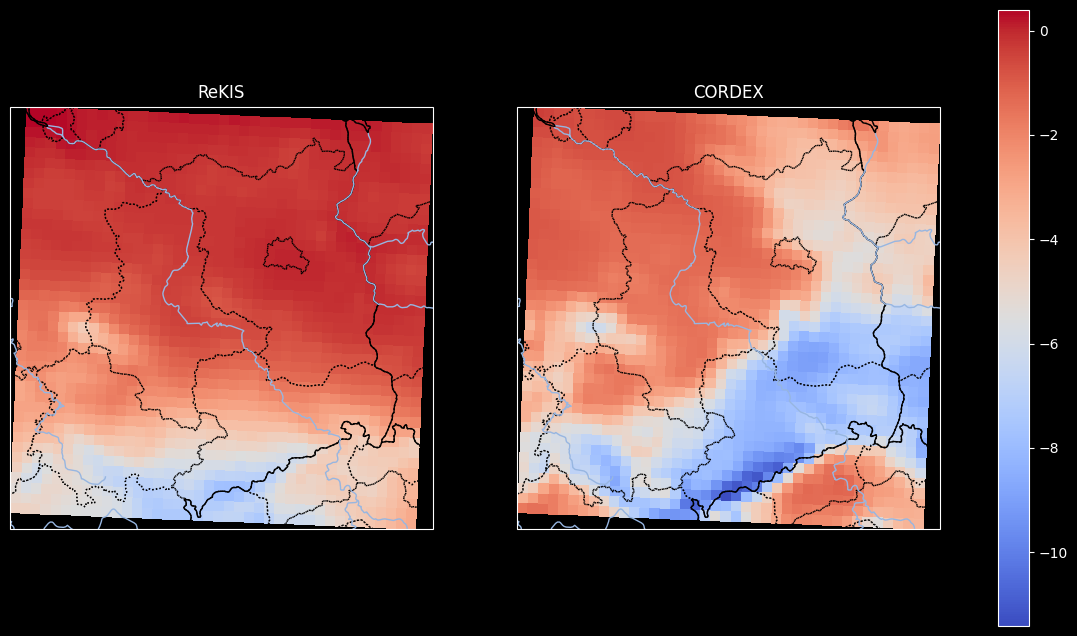

In [59]:
fig, axes = plt.subplots(ncols=2, subplot_kw=dict(projection=cartopy.crs.UTM(33)), figsize = (15, 8))
minimum = min(x_example.min(), x_cordex_example.min())
maximum = max(x_example.max(), x_cordex_example.max())
norm = matplotlib.colors.Normalize(vmin=minimum, vmax=maximum)
im = x_example.plot(
    ax=axes[0],
    cmap="coolwarm",
    center=0,
    transform=cartopy.crs.epsg(31468),
    add_colorbar=False,
    norm=norm,
)
x_cordex_example.plot(
    ax=axes[1],
    cmap="coolwarm",
    center=0,
    transform=cartopy.crs.epsg(31468),
    add_colorbar=False,
    norm=norm,
)
fig.colorbar(im, ax=axes)
axes[0].set_title("ReKIS")
axes[1].set_title("CORDEX")
for ax in axes:
    ax.add_feature(cartopy.feature.BORDERS)
    ax.add_feature(cartopy.feature.STATES, linestyle=":")
    ax.add_feature(cartopy.feature.RIVERS)
    ax.add_feature(cartopy.feature.COASTLINE)